# Real-Time Retail Analytics

## Project Overview

This project focuses on analyzing retail customer behaviour and sales patterns using data analytics techniques to generate meaningful business insights.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
file_path = "data/raw/Sample - Superstore.csv"

data = pd.read_csv(file_path, encoding="latin1")

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
data.shape

(9994, 21)

In [12]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [13]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [15]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [16]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [19]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

data.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [20]:
data["Order Year"] = data["Order Date"].dt.year

data["Order Month"] = data["Order Date"].dt.month_name()

data["Shipping Days"] = (data["Ship Date"] - data["Order Date"]).dt.days

data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,7


In [21]:
data.to_csv("data/processed/cleaned_superstore_data.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# Exploratory Data Analysis (EDA)

## 1. Overall Business Performance

This section analyzes overall sales, profit, and quantity sold to understand the performance of the retail business.

In [22]:
data[["Sales", "Profit", "Quantity"]].describe()

,Sales,Profit,Quantity
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574
std,623.245101,234.260108,2.225110
min,0.444000,-6599.978000,1.000000
25%,17.280000,1.728750,2.000000
50%,54.490000,8.666500,3.000000
75%,209.940000,29.364000,5.000000
max,22638.480000,8399.976000,14.000000


In [23]:
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_quantity = data["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity Sold: 37873


### Observation

The dataset contains **9,994 retail transactions**.

The business generated a **total sales revenue of 2,297,200.86**, earned a **total profit of 286,397.02**, and sold **37,873 products** during the recorded period.

These KPIs provide an overall understanding of the company's business performance before performing detailed analysis.

## 2. Sales by Category

This analysis identifies which product category contributes the highest sales revenue.

In [24]:
category_sales = data.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

### Observation

Technology generated the highest total sales (836,154.03), followed by Furniture (741,999.80) and Office Supplies (719,047.03). This indicates that Technology products contribute the highest revenue among all product categories.

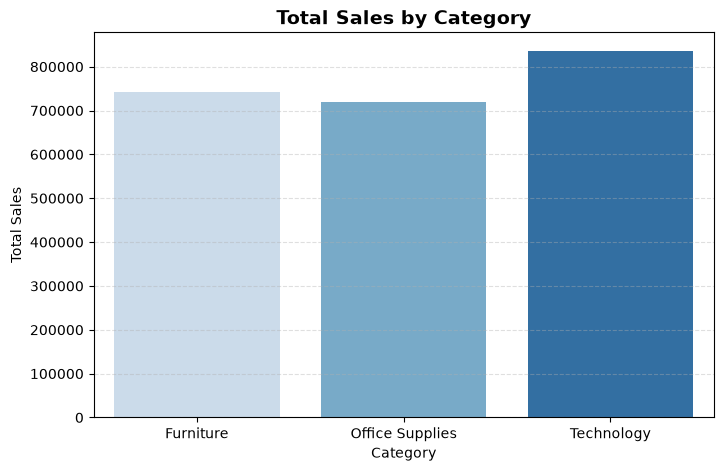

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette="Blues",
    legend=False
)

plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/sales_by_category.png", bbox_inches="tight")
plt.show()

### Observation

The Technology category recorded the highest sales, followed by Furniture and Office Supplies. This indicates that Technology products contribute the largest share of revenue in the retail business.

### Business Insight

The Technology category generates the highest sales revenue, making it the strongest performing product category. The company should continue investing in Technology products through inventory planning, promotions, and marketing campaigns. Office Supplies has the lowest sales, so strategies such as targeted discounts or product bundling could be used to improve its performance.

## 3. Profit by Category

This analysis identifies which product category generates the highest profit for the business.

In [26]:
category_profit = data.groupby("Category")["Profit"].sum()

category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

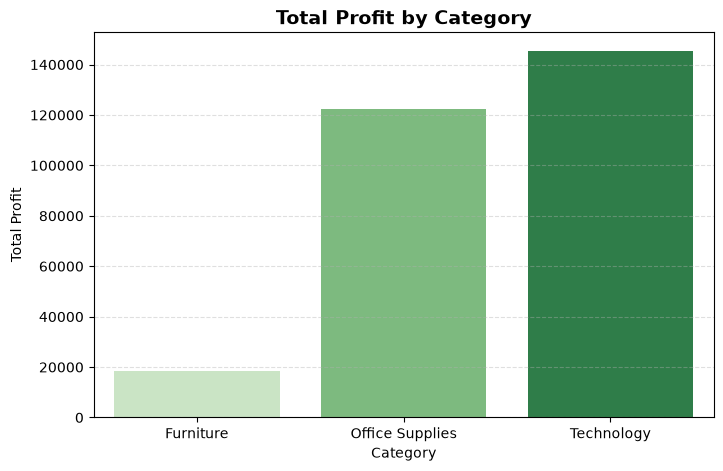

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    hue=category_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Total Profit by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/profit_by_category.png", bbox_inches="tight")
plt.show()

### Observation

The Technology category generated the highest total profit (145,454.95), followed by Office Supplies (122,490.80). Although Furniture recorded high sales, it generated the lowest profit (18,451.27), indicating that higher sales do not necessarily result in higher profitability.

### Business Insight

Technology is the most profitable product category and should remain a key focus for business growth. The low profit from Furniture, despite its high sales, suggests that pricing strategies, discounts, or product costs should be reviewed to improve profitability.

## 4. Sales by Sub-Category

This analysis identifies the sub-categories that generate the highest sales revenue.

In [74]:
subcategory_sales = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

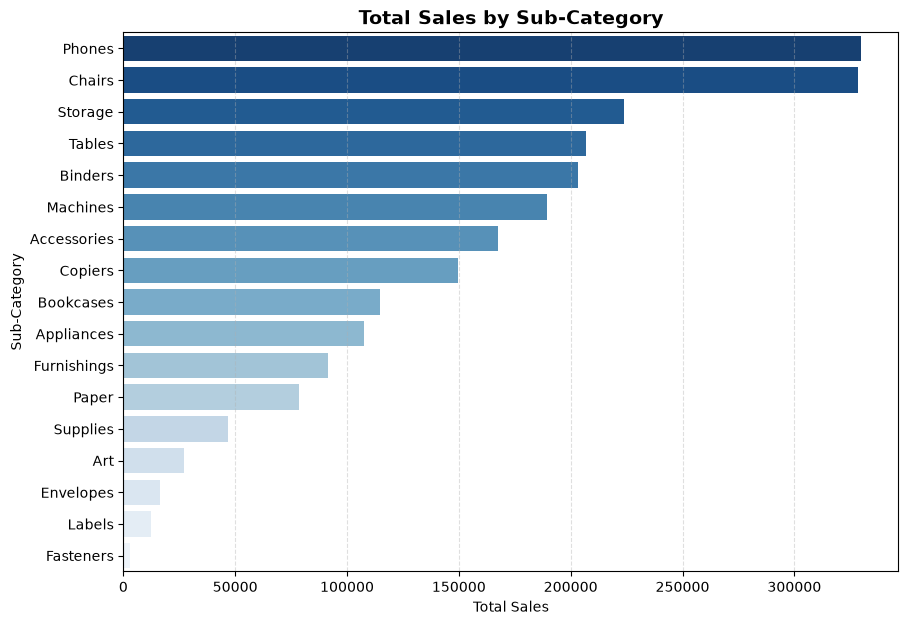

In [75]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index,
    hue=subcategory_sales.index,
    palette="Blues_r",
    legend=False
)

plt.title("Total Sales by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/sales_by_subcategory.png", bbox_inches="tight")
plt.show()

### Observation

The Phones sub-category generated the highest sales (330,007.05), closely followed by Chairs (328,449.10). Storage, Tables, and Binders also contributed significantly to total sales. Fasteners recorded the lowest sales among all sub-categories.

### Business Insight

The company should continue focusing on high-performing sub-categories such as Phones and Chairs by ensuring adequate inventory and effective marketing. Low-performing sub-categories, such as Fasteners, should be reviewed to determine whether improvements in pricing, promotion, or product assortment are needed.

## 5. Profit by Sub-Category

This analysis identifies the sub-categories that generate the highest profit for the business.

In [76]:
subcategory_profit = data.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

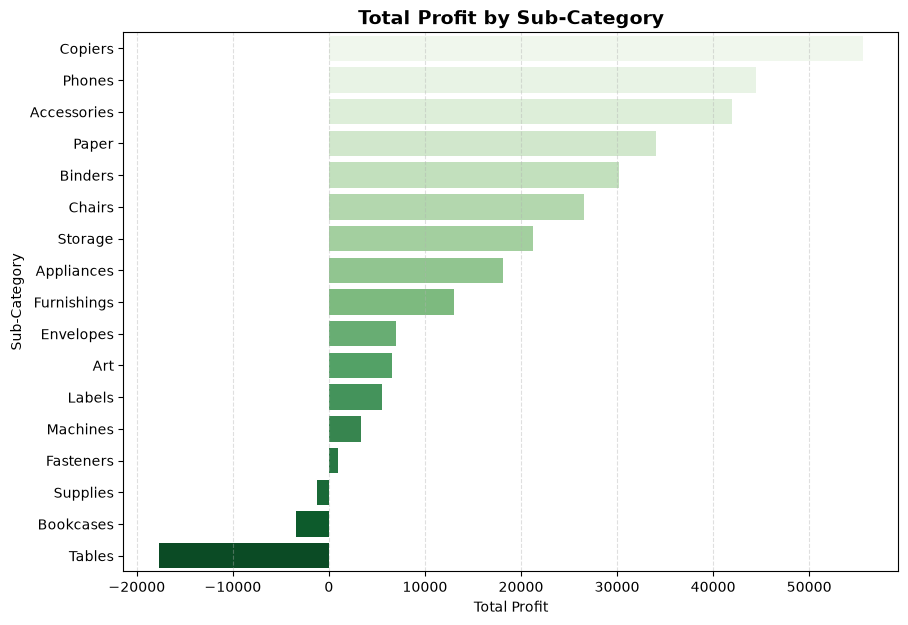

In [77]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index,
    hue=subcategory_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Total Profit by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/profit_by_subcategory.png", bbox_inches="tight")

plt.show()

### Observation

Copiers generated the highest total profit (55,617.82), followed by Phones (44,515.73) and Accessories (41,936.64). In contrast, Tables (-17,725.48), Bookcases (-3,472.56), and Supplies (-1,189.10) recorded negative profits, indicating that these sub-categories resulted in business losses.

### Business Insight

The company should continue investing in high-profit sub-categories such as Copiers, Phones, and Accessories. Loss-making sub-categories like Tables, Bookcases, and Supplies should be investigated by reviewing pricing, discounts, procurement costs, and customer demand to improve profitability.

## 6. Sales by Region

This analysis identifies the regions that contribute the highest sales revenue.

In [78]:
region_sales = data.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

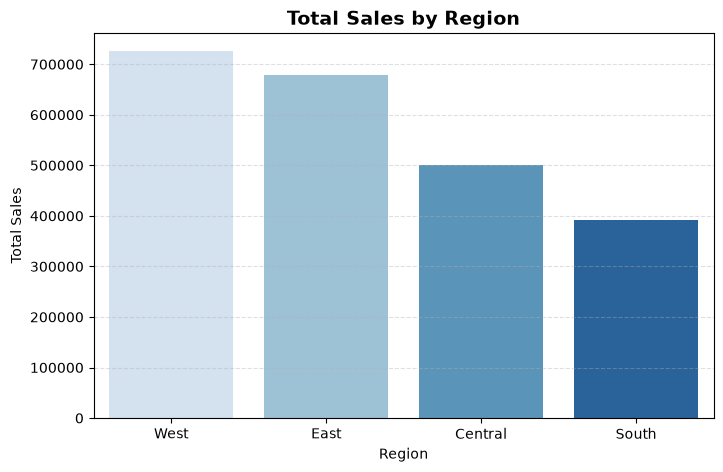

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="Blues",
    legend=False
)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/sales_by_region.png", bbox_inches="tight")

plt.show()

### Observation

The West region generated the highest sales revenue (725,457.82), followed by the East region (678,781.24). The Central region contributed moderate sales, while the South region recorded the lowest sales among all regions.

### Business Insight

The company should continue focusing on the West and East regions as they are the strongest revenue-generating areas. Additional marketing campaigns and customer engagement strategies can be considered for the South region to improve its sales performance.

## 7. Profit by Region

This analysis identifies which regions generate the highest profit for the business.

In [80]:
region_profit = data.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

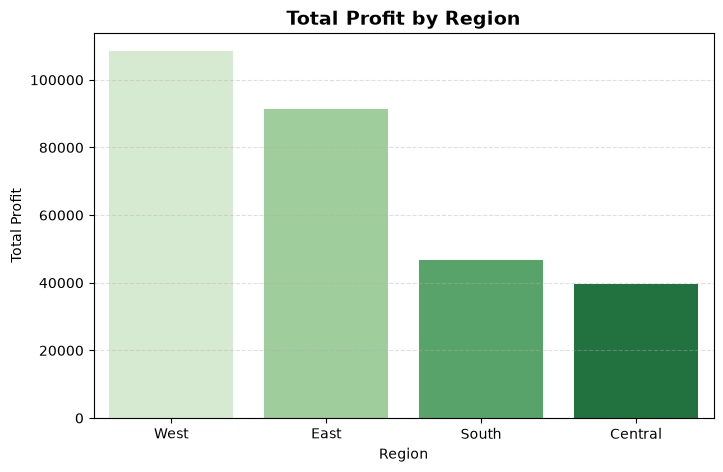

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values,
    hue=region_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Total Profit by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/profit_by_region.png", bbox_inches="tight")

plt.show()

### Observation

The West region generated the highest profit (108,418.45), followed by the East region (91,522.78). The South and Central regions generated comparatively lower profits, with the Central region recording the lowest profit among all regions.

### Business Insight

The West and East regions are the strongest contributors to business profitability. The company should continue focusing on these regions while analyzing customer behavior and pricing strategies in the Central and South regions to improve their profit contribution.

## 8. Sales by State (Top 10)

This analysis identifies the top-performing states based on total sales revenue.

In [82]:
state_sales = data.groupby("State")["Sales"].sum().sort_values(ascending=False)

top10_states_sales = state_sales.head(10)

top10_states_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

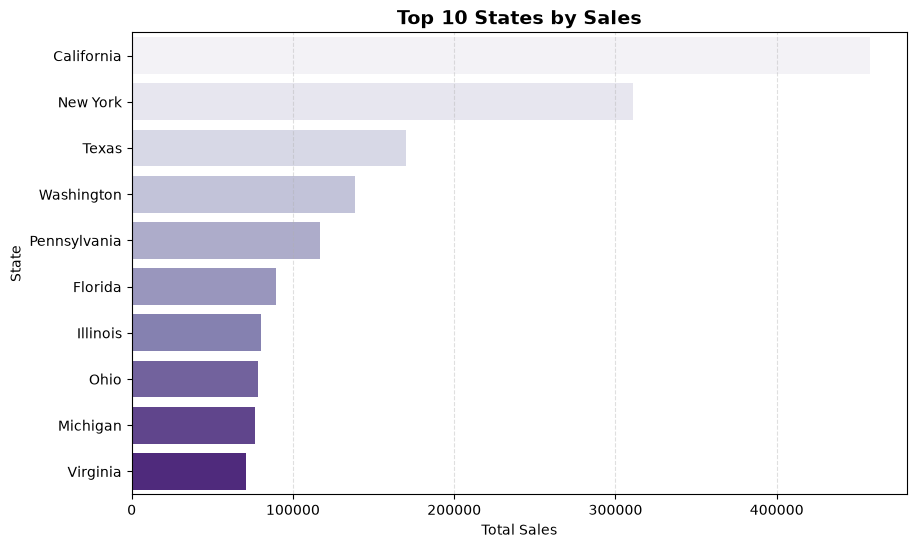

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_states_sales.values,
    y=top10_states_sales.index,
    hue=top10_states_sales.index,
    palette="Purples",
    legend=False
)

plt.title("Top 10 States by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_states_sales.png", bbox_inches="tight")

plt.show()

### Observation

California generated the highest sales revenue (457,687.63), followed by New York (310,876.27) and Texas (170,188.05). The remaining states contributed comparatively lower sales. This shows that sales are highly concentrated in a few major states, especially California and New York.

### Business Insight

The company should continue strengthening its presence in high-performing states such as California and New York through targeted marketing and customer retention strategies. For lower-performing states, the company can explore promotional campaigns and analyze customer demand to increase sales growth.

## 9. Profit by State (Top 10)

This analysis identifies the top-performing states based on total profit generated.

In [84]:
state_profit = data.groupby("State")["Profit"].sum().sort_values(ascending=False)

top10_states_profit = state_profit.head(10)

top10_states_profit

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

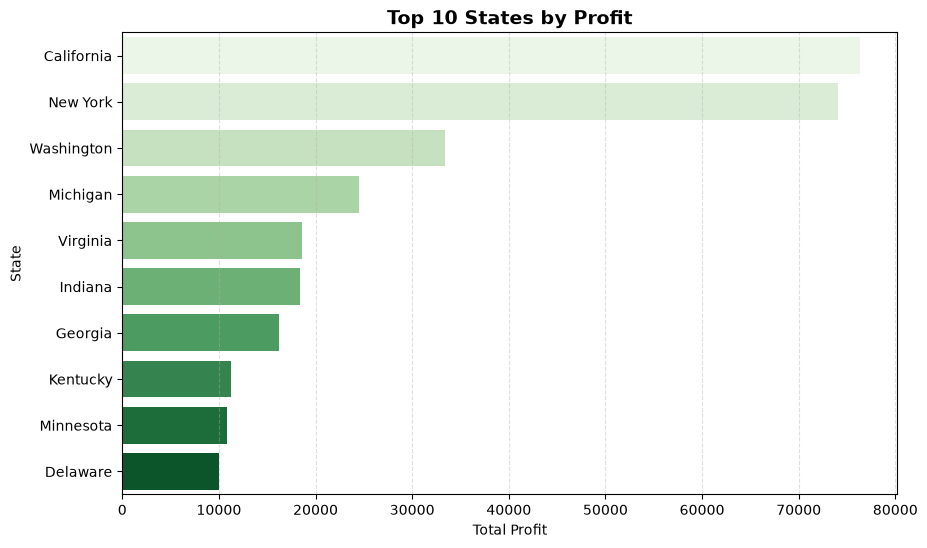

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_states_profit.values,
    y=top10_states_profit.index,
    hue=top10_states_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Top 10 States by Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_states_profit.png", bbox_inches="tight")

plt.show()

### Observation

California generated the highest profit (76,381.39), followed closely by New York (74,038.55). Washington, Michigan, and Virginia also contributed significantly to total profit. The results show that California and New York are the strongest profit-generating states for the business.

### Business Insight

The company should prioritize customer retention and marketing strategies in highly profitable states such as California and New York. For other states with lower profitability, the company can analyze pricing, discounts, and customer preferences to identify opportunities for improvement.

## 10. Customer Segment Analysis

This analysis identifies which customer segment contributes the highest sales revenue.

In [86]:
segment_sales = data.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

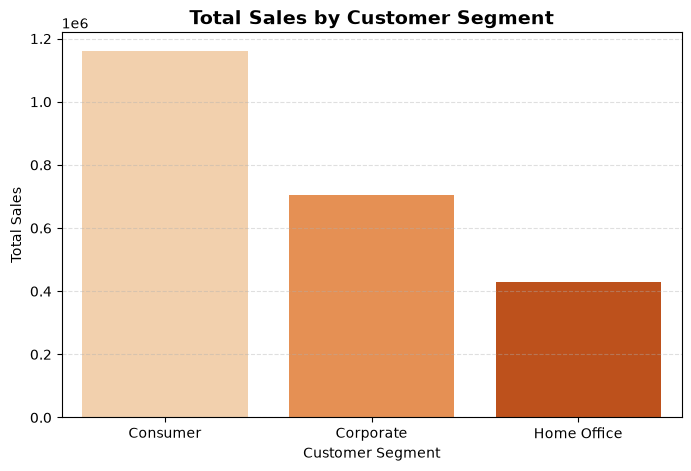

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    hue=segment_sales.index,
    palette="Oranges",
    legend=False
)

plt.title("Total Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/sales_by_segment.png", bbox_inches="tight")

plt.show()

### Observation

The Consumer segment generated the highest sales revenue (1,161,401.35), followed by the Corporate segment (706,146.37). The Home Office segment contributed the lowest sales (429,653.15). This indicates that individual consumers are the primary revenue contributors for the business.

### Business Insight

The company should focus on retaining and expanding the Consumer customer base through personalized marketing campaigns and loyalty programs. The Corporate segment also represents a valuable market opportunity, while strategies can be developed to increase engagement from Home Office customers.

## 11. Profit by Customer Segment

This analysis identifies which customer segment contributes the highest profit to the business.

In [88]:
segment_profit = data.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

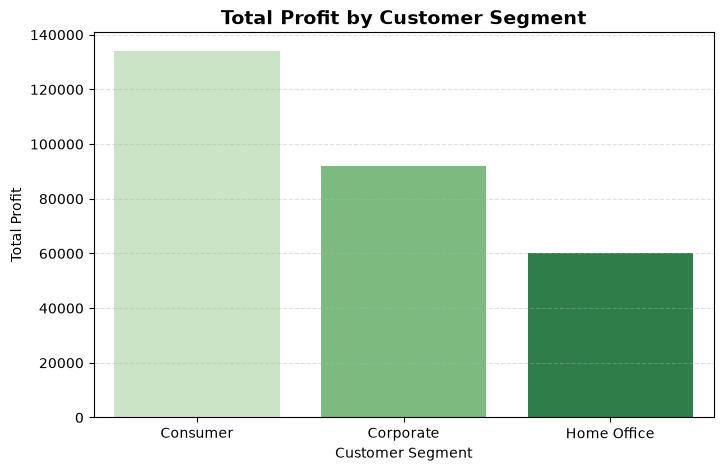

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values,
    hue=segment_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Total Profit by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/profit_by_segment.png", bbox_inches="tight")

plt.show()

### Observation

The Consumer segment generated the highest profit (134,119.21), followed by the Corporate segment (91,979.13). The Home Office segment contributed the lowest profit (60,298.68). The results indicate that Consumer customers are the most valuable segment in terms of both sales and profitability.

### Business Insight

The company should focus on strengthening relationships with Consumer customers through loyalty programs, personalized offers, and targeted promotions. Corporate and Home Office segments can be further developed by understanding their purchasing patterns and creating suitable strategies to increase profitability.

## 12. Monthly Sales Trend Analysis

This analysis examines the change in sales over time to identify monthly sales patterns and trends.

In [90]:
data["Month_Year"] = data["Order Date"].dt.to_period("M")

data[["Order Date", "Month_Year"]].head()

,Order Date,Month_Year
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [91]:
monthly_sales = data.groupby("Month_Year")["Sales"].sum()

monthly_sales

Month_Year
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


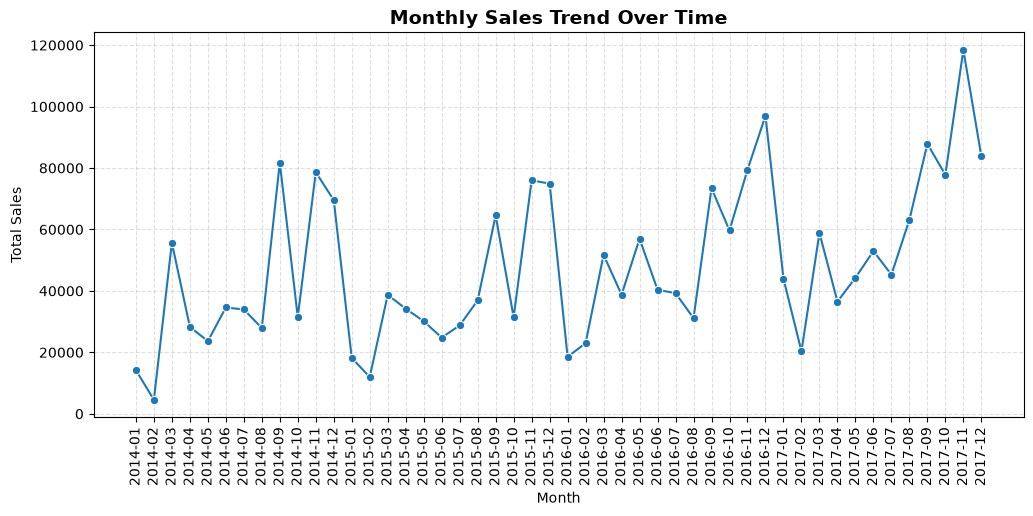

In [92]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index.astype(str),
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("screenshots/monthly_sales_trend.png", bbox_inches="tight")

plt.show()

### Observation

The monthly sales trend shows variations in sales performance over time. Sales increased gradually from 2014 to 2017, indicating business growth. The highest sales were recorded in November 2017 (118,447.83), followed by December 2016 (96,999.04). November and December generally show higher sales, suggesting seasonal demand during the year-end period.

### Business Insight

The company should prepare sufficient inventory and promotional strategies before high-demand periods, especially during November and December. Understanding seasonal sales patterns can help improve stock planning, marketing campaigns, and overall business performance.

## 13. Monthly Profit Trend Analysis

This analysis examines changes in profit over time to identify monthly profitability patterns.

In [93]:
monthly_profit = data.groupby("Month_Year")["Profit"].sum()

monthly_profit

Month_Year
2014-01     2450.1907
2014-02      862.3084
2014-03      498.7299
2014-04     3488.8352
2014-05     2738.7096
2014-06     4976.5244
2014-07     -841.4826
2014-08     5318.1050
2014-09     8328.0994
2014-10     3448.2573
2014-11     9292.1269
2014-12     8983.5699
2015-01    -3281.0070
2015-02     2813.8508
2015-03     9732.0978
2015-04     4187.4962
2015-05     4667.8690
2015-06     3335.5572
2015-07     3288.6483
2015-08     5355.8084
2015-09     8209.1627
2015-10     2817.3660
2015-11    12474.7884
2015-12     8016.9659
2016-01     2824.8233
2016-02     5004.5795
2016-03     3611.9680
2016-04     2977.8149
2016-05     8662.1464
2016-06     4750.3781
2016-07     4432.8779
2016-08     2062.0693
2016-09     9328.6576
2016-10    16243.1425
2016-11     4011.4075
2016-12    17885.3093
2017-01     7140.4391
2017-02     1613.8720
2017-03    14751.8915
2017-04      933.2900
2017-05     6342.5828
2017-06     8223.3357
2017-07     6952.6212
2017-08     9040.9557
2017-09    10991.5556

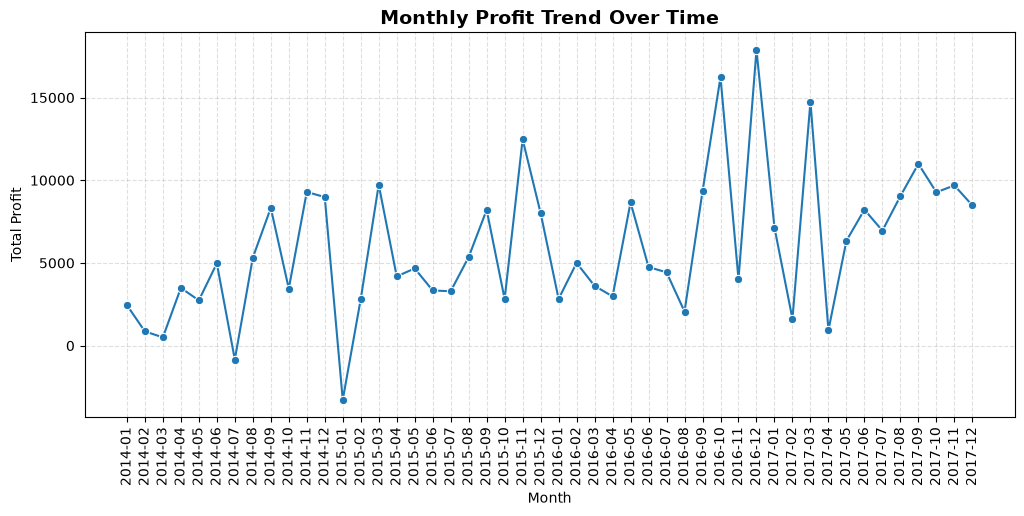

In [94]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_profit.index.astype(str),
    y=monthly_profit.values,
    marker="o"
)

plt.title("Monthly Profit Trend Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(rotation=90)

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("screenshots/monthly_profit_trend.png", bbox_inches="tight")

plt.show()

### Observation

The monthly profit trend shows fluctuations in profitability over time. The highest profit was recorded in December 2016 (17,885.31), followed by October 2016 (16,243.14) and March 2017 (14,751.89). Some months, such as January 2015 and July 2014, recorded negative profits, indicating periods of business losses.

### Business Insight

The company should analyze the factors behind low-profit and loss-making months, such as excessive discounts, operational costs, or product pricing. Maintaining strategies used during high-profit periods can help improve overall profitability and reduce future losses.

## 14. Discount Analysis

This analysis examines discount patterns and their impact on different product categories.

In [95]:
category_discount = data.groupby("Category")["Discount"].mean()

category_discount

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

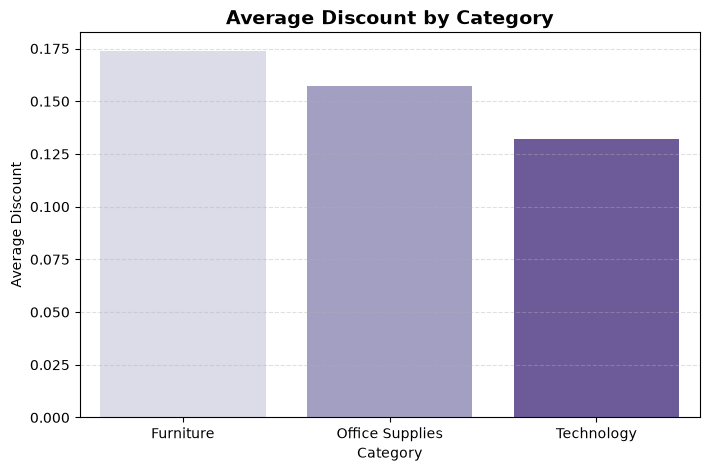

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_discount.index,
    y=category_discount.values,
    hue=category_discount.index,
    palette="Purples",
    legend=False
)

plt.title("Average Discount by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/average_discount_by_category.png", bbox_inches="tight")

plt.show()

### Observation

Furniture products received the highest average discount (17.39%), followed by Office Supplies (15.73%) and Technology (13.23%). The company appears to provide higher discounts for Furniture products compared to other categories.

### Business Insight

The company should evaluate whether higher discounts on Furniture products are improving sales and profitability. Discount strategies should be optimized to increase customer demand while maintaining healthy profit margins.

## 15. Discount Impact on Profit

This analysis examines how different discount levels influence profit generation.

In [97]:
discount_profit = data.groupby("Discount")["Profit"].mean().sort_index()

discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

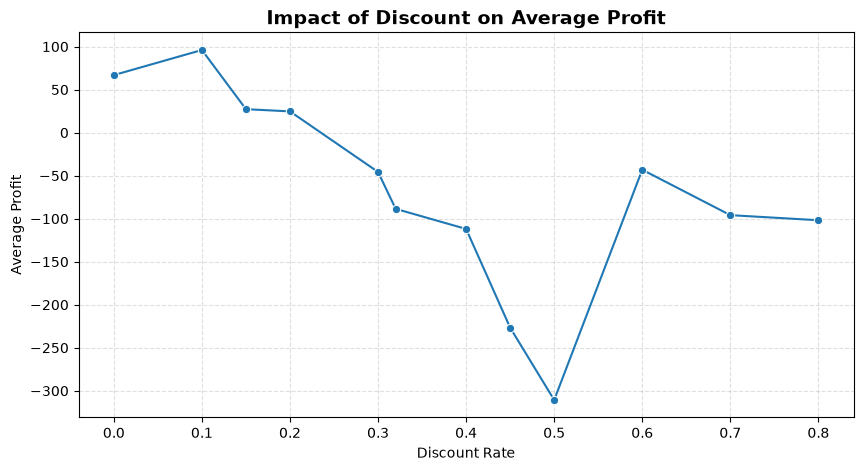

In [101]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=discount_profit.index,
    y=discount_profit.values,
    marker="o"
)

plt.title("Impact of Discount on Average Profit", fontsize=14, fontweight="bold")
plt.xlabel("Discount Rate")
plt.ylabel("Average Profit")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("screenshots/discount_vs_profit.png", bbox_inches="tight")

plt.show()

### Observation

The analysis shows that lower discount levels generally maintain positive average profit. Discounts up to 20% resulted in positive profitability, while higher discounts, especially above 30%, caused negative average profit. The highest loss was observed at a 50% discount level.

### Business Insight

The company should avoid excessive discounting and establish an optimal discount strategy. Discounts should be offered carefully to increase customer demand without significantly reducing profit margins. Data-driven discount policies can help maintain profitability while attracting customers.

## 16. Sales vs Profit Relationship

This analysis examines the relationship between sales revenue and profit to understand how sales performance impacts profitability.

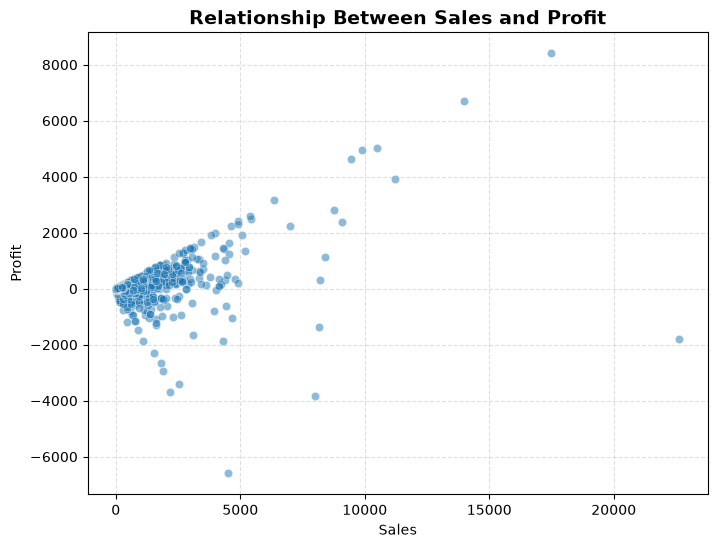

In [102]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Sales and Profit", fontsize=14, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("screenshots/sales_vs_profit.png", bbox_inches="tight")

plt.show()

### Observation

The scatter plot shows a positive relationship between sales and profit, where higher sales transactions generally tend to generate higher profits. However, some transactions with high sales values also resulted in low or negative profits, indicating that factors such as discounts and product costs influence profitability.

### Business Insight

The company should focus not only on increasing sales volume but also on improving profit margins. High-sales products with low or negative profits should be reviewed for pricing, discount strategies, and cost optimization to ensure sustainable growth.

## 17. Product Performance Analysis

This analysis identifies the top-performing products based on total sales revenue.

In [103]:
product_sales = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

top10_products_sales = product_sales.head(10)

top10_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

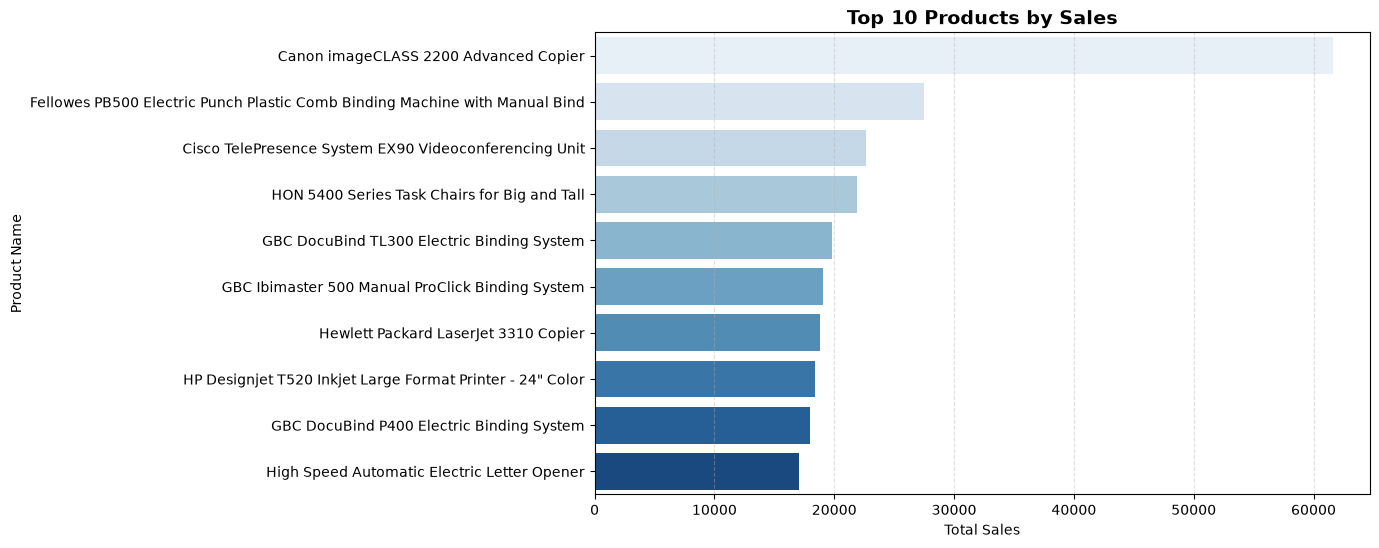

In [104]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_products_sales.values,
    y=top10_products_sales.index,
    hue=top10_products_sales.index,
    palette="Blues",
    legend=False
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_products_sales.png", bbox_inches="tight")

plt.show()

### Observation

The Canon imageCLASS 2200 Advanced Copier generated the highest sales revenue (61,599.82), significantly higher than other products. Most of the top-selling products belong to the Technology category, including copiers, printers, and office equipment. This indicates strong demand for technology-related products.

### Business Insight

The company should ensure continuous availability of high-performing products such as copiers and printers to avoid missed sales opportunities. Inventory planning and targeted promotions for these products can help maximize revenue.

## 18. Top 10 Products by Profit

This analysis identifies the products that generate the highest profit for the business.

In [105]:
product_profit = data.groupby("Product Name")["Profit"].sum().sort_values(ascending=False)

top10_products_profit = product_profit.head(10)

top10_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

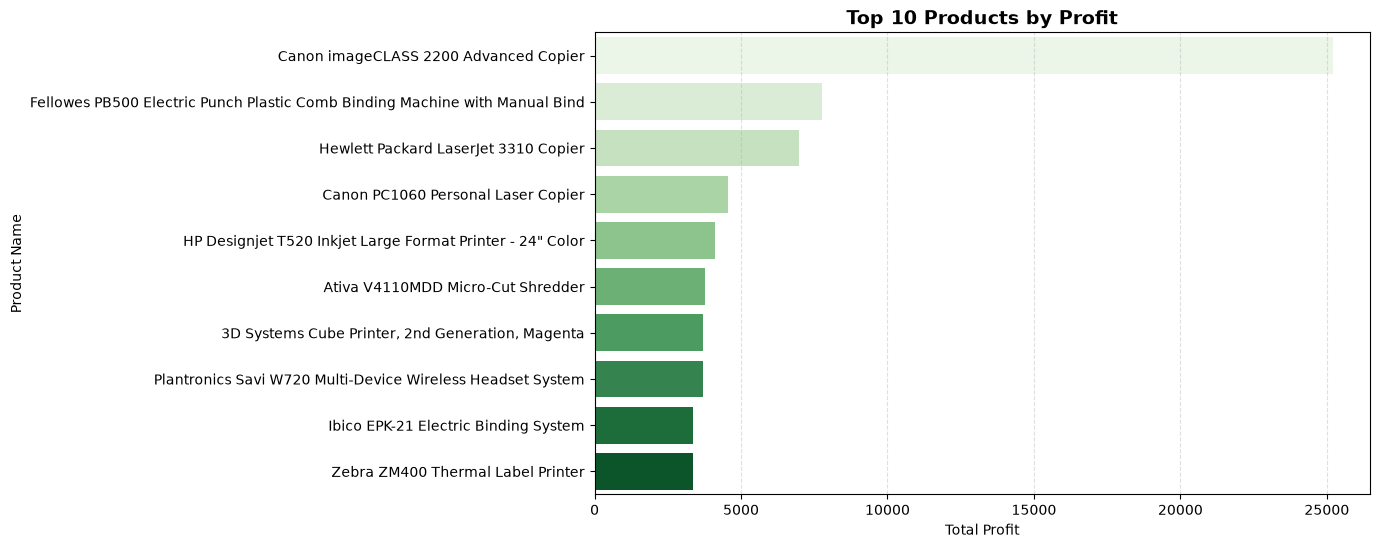

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_products_profit.values,
    y=top10_products_profit.index,
    hue=top10_products_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Top 10 Products by Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_products_profit.png", bbox_inches="tight")

plt.show()

### Observation

The Canon imageCLASS 2200 Advanced Copier generated the highest profit (25,199.93), significantly outperforming other products. Most of the top profitable products belong to the Technology category, especially copiers, printers, and electronic office equipment. These products contribute strongly to the company's profitability.

### Business Insight

The company should focus on maintaining sufficient inventory and promoting high-profit products such as copiers and printers. Identifying and prioritizing profitable products can help improve revenue quality and support better product management decisions.

## 19. Quantity Sold Analysis

This analysis identifies which product categories have the highest number of units sold.

In [107]:
category_quantity = data.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity

Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64

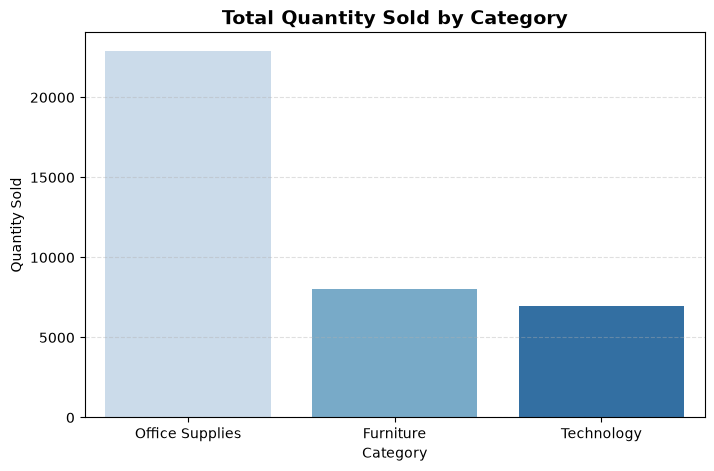

In [108]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values,
    hue=category_quantity.index,
    palette="Blues",
    legend=False
)

plt.title("Total Quantity Sold by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("screenshots/quantity_by_category.png", bbox_inches="tight")

plt.show()

### Observation

Office Supplies recorded the highest quantity sold with 22,906 units, followed by Furniture with 8,028 units and Technology with 6,939 units. The results indicate that Office Supplies are the fastest-moving products with higher customer purchase frequency.

### Business Insight

The company should maintain higher inventory levels for Office Supplies to meet continuous customer demand. For Furniture and Technology products, strategies should focus on improving customer engagement and increasing purchase volume while maintaining profitability.

In [109]:
subcategory_quantity = data.groupby("Sub-Category")["Quantity"].sum().sort_values(ascending=False)

subcategory_quantity

Sub-Category
Binders        5974
Paper          5178
Furnishings    3563
Phones         3289
Storage        3158
Art            3000
Accessories    2976
Chairs         2356
Appliances     1729
Labels         1400
Tables         1241
Fasteners       914
Envelopes       906
Bookcases       868
Supplies        647
Machines        440
Copiers         234
Name: Quantity, dtype: int64

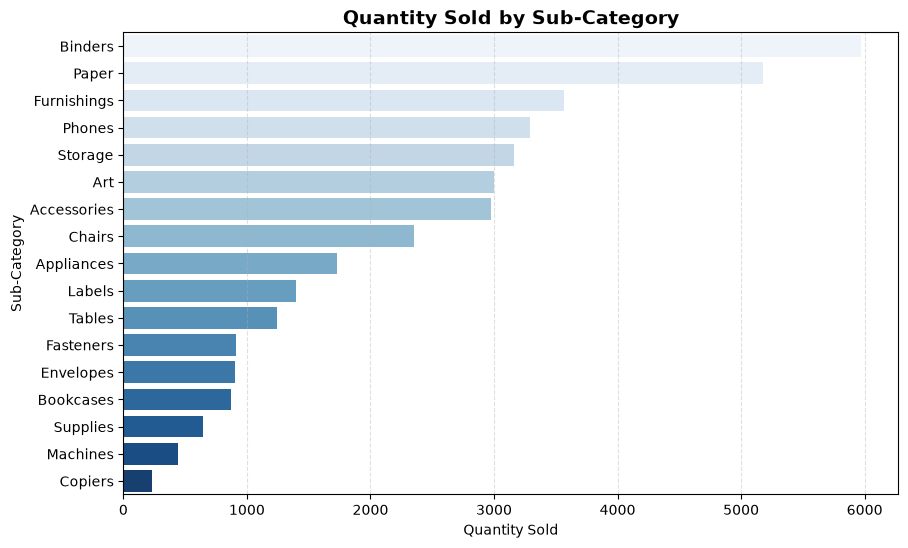

In [110]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=subcategory_quantity.values,
    y=subcategory_quantity.index,
    hue=subcategory_quantity.index,
    palette="Blues",
    legend=False
)

plt.title("Quantity Sold by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Sub-Category")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/quantity_by_subcategory.png", bbox_inches="tight")

plt.show()

### Observation

Binders recorded the highest quantity sold with 5,974 units, followed by Paper with 5,178 units. Office-related products dominate the highest-selling sub-categories, indicating frequent customer demand for regularly used business supplies.

### Business Insight

The company should maintain adequate inventory levels for high-demand sub-categories such as Binders and Paper to avoid stock shortages. Regular monitoring of fast-moving products can improve inventory management and customer satisfaction.

In [111]:
customer_sales = data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

top10_customers_sales = customer_sales.head(10)

top10_customers_sales

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

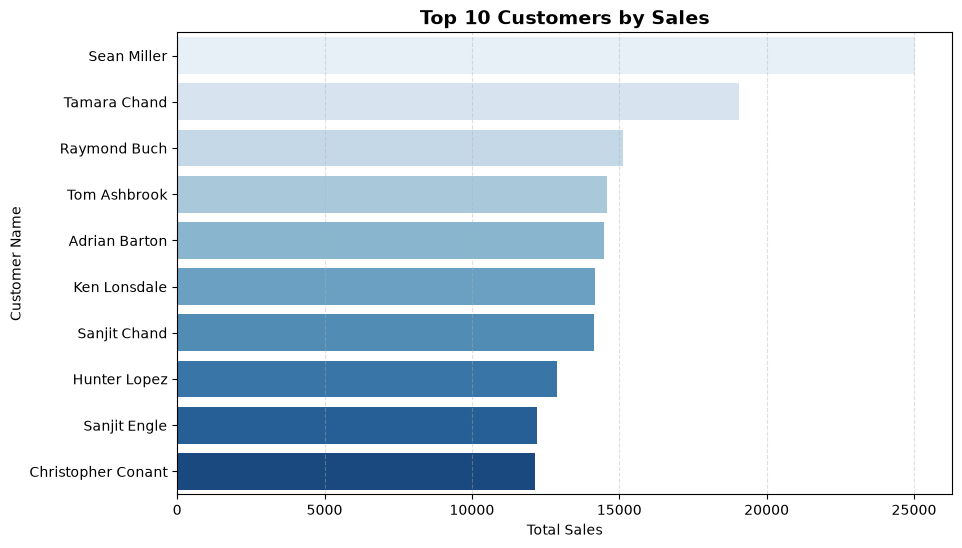

In [112]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_customers_sales.values,
    y=top10_customers_sales.index,
    hue=top10_customers_sales.index,
    palette="Blues",
    legend=False
)

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_customers_sales.png", bbox_inches="tight")

plt.show()

### Observation

Sean Miller generated the highest sales revenue among all customers with total sales of 25,043.05, followed by Tamara Chand with 19,052.22. The top customers contribute significantly to overall sales and represent important customer segments for the business.

### Business Insight

The company should focus on retaining high-value customers through personalized offers, loyalty programs, and targeted marketing strategies. Understanding customer contribution helps improve customer relationship management and revenue growth.

In [113]:
customer_profit = data.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)

top10_customers_profit = customer_profit.head(10)

top10_customers_profit

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

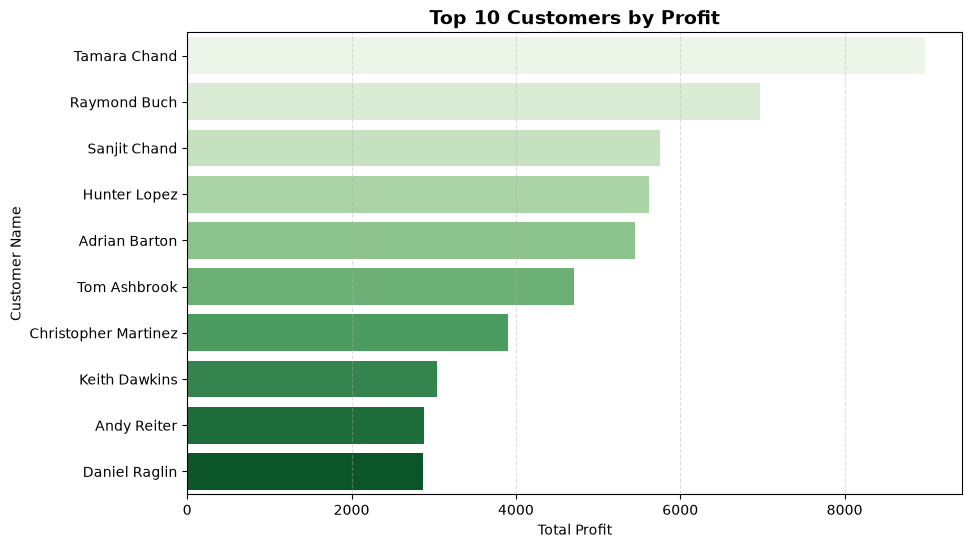

In [114]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10_customers_profit.values,
    y=top10_customers_profit.index,
    hue=top10_customers_profit.index,
    palette="Greens",
    legend=False
)

plt.title("Top 10 Customers by Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/top10_customers_profit.png", bbox_inches="tight")

plt.show()

### Observation

Tamara Chand generated the highest profit among customers with a total profit of 8,981.32, followed by Raymond Buch with 6,976.10. The results show that the customers generating the highest sales are not always the most profitable, highlighting the importance of analyzing profitability separately.

### Business Insight

The company should focus on retaining customers who contribute higher profits through loyalty programs and personalized services. Customer evaluation should consider both revenue contribution and profitability to make better business decisions.

In [115]:
correlation = data[["Sales", "Quantity", "Discount", "Profit"]].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


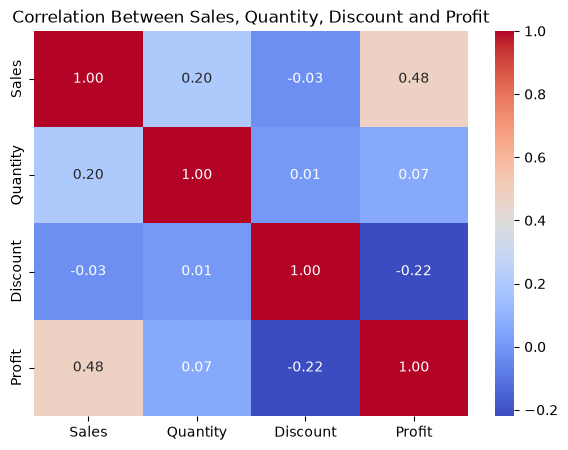

In [116]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Sales, Quantity, Discount and Profit")

plt.savefig("screenshots/correlation_heatmap.png", bbox_inches="tight")

plt.show()

### Observation

The correlation analysis shows that Sales has a moderate positive relationship with Profit (0.48), indicating that higher sales generally contribute to higher profit. Discount has a negative relationship with Profit (-0.22), suggesting that excessive discounts can reduce profitability. Quantity has a very weak relationship with Profit, meaning higher sales volume alone does not guarantee increased profit.

### Business Insight

The company should focus on increasing sales through profitable strategies rather than relying heavily on discounts. Pricing optimization and controlled discount policies can help improve profit margins. Business decisions should consider both sales growth and profitability.

In [117]:
customer_data = data.groupby("Customer Name").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum",
    "Discount": "mean"
})

customer_data.head()

,Sales,Quantity,Profit,Discount
Customer Name,,,,
Aaron Bergman,886.156,13,129.3465,0.066667
Aaron Hawkins,1744.700,54,365.2152,0.090909
Aaron Smayling,3050.692,48,-253.5746,0.355000
Adam Bellavance,7755.620,56,2054.5885,0.044444
Adam Hart,3250.337,75,281.1890,0.135000


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

customer_scaled = scaler.fit_transform(customer_data)

customer_scaled[:5]

array([[-0.76539139, -1.40004016, -0.25938287, -1.02022722],
       [-0.43857753,  0.25137131,  0.00454158, -0.74788484],
       [ 0.05856216,  0.00970134, -0.68785109,  2.21894503],
       [ 1.84954282,  0.33192797,  1.89485991, -1.26987441],
       [ 0.13455914,  1.09721621, -0.08947924, -0.25256212]])

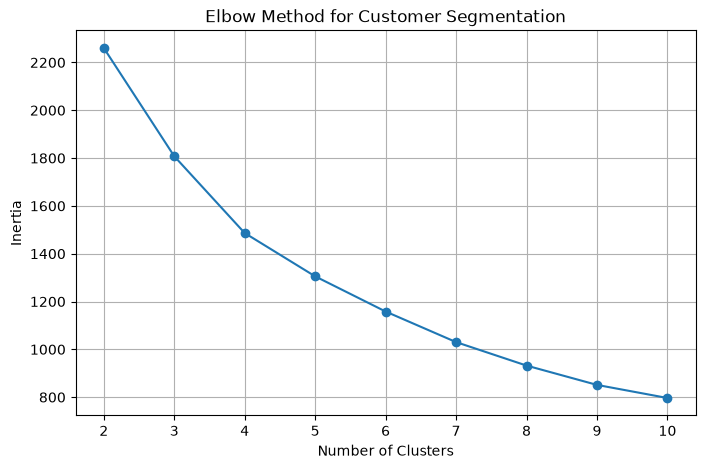

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Customer Segmentation")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.savefig("screenshots/elbow_method.png", bbox_inches="tight")

plt.show()

In [29]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

customer_data["Cluster"] = kmeans.fit_predict(customer_scaled)

customer_data.head()

,Sales,Quantity,Profit,Discount,Cluster
Customer Name,,,,,
Aaron Bergman,886.156,13,129.3465,0.066667,4
Aaron Hawkins,1744.700,54,365.2152,0.090909,4
Aaron Smayling,3050.692,48,-253.5746,0.355000,1
Adam Bellavance,7755.620,56,2054.5885,0.044444,0
Adam Hart,3250.337,75,281.1890,0.135000,2


In [30]:
cluster_summary = customer_data.groupby("Cluster").mean()

cluster_summary

,Sales,Quantity,Profit,Discount
Cluster,,,,
0,7045.287384,73.884615,1372.343577,0.118874
1,1471.654016,30.299435,-106.172948,0.262288
2,3392.290879,70.659686,134.136041,0.186921
3,14172.628571,56.142857,5912.249300,0.104704
4,1773.478515,34.831210,304.013289,0.094459


In [31]:
cluster_names = {
    0: "High-Value Customers",
    1: "Low-Profit Customers",
    2: "Regular High-Volume Customers",
    3: "Premium Customers",
    4: "Low-Value Profitable Customers"
}

customer_data["Customer Segment"] = customer_data["Cluster"].map(cluster_names)

customer_data.head()

,Sales,Quantity,Profit,Discount,Cluster,Customer Segment
Customer Name,,,,,,
Aaron Bergman,886.156,13,129.3465,0.066667,4,Low-Value Profitable Customers
Aaron Hawkins,1744.700,54,365.2152,0.090909,4,Low-Value Profitable Customers
Aaron Smayling,3050.692,48,-253.5746,0.355000,1,Low-Profit Customers
Adam Bellavance,7755.620,56,2054.5885,0.044444,0,High-Value Customers
Adam Hart,3250.337,75,281.1890,0.135000,2,Regular High-Volume Customers


In [32]:
segment_counts = customer_data["Customer Segment"].value_counts()

segment_counts

Customer Segment
Low-Value Profitable Customers    314
Regular High-Volume Customers     191
Low-Profit Customers              177
High-Value Customers              104
Premium Customers                   7
Name: count, dtype: int64

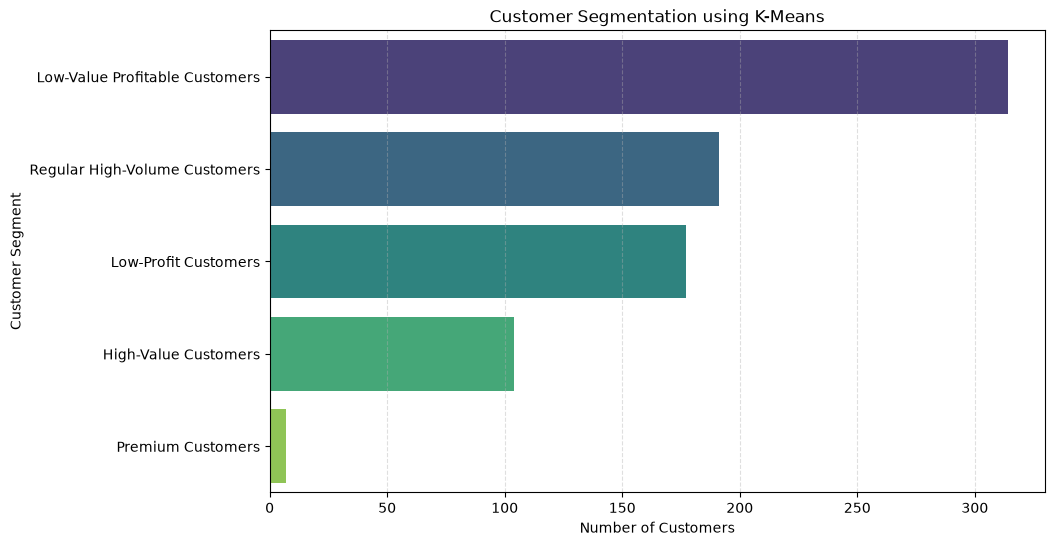

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    hue=segment_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.savefig("screenshots/customer_segmentation.png", bbox_inches="tight")

plt.show()

### Observation

The K-Means clustering analysis divided customers into five segments based on their sales, quantity, profit, and discount behavior. The largest group is Low-Value Profitable Customers with 314 customers, while Premium Customers form the smallest group with only 7 customers. Low-Profit Customers include 177 customers and show negative average profit with relatively higher discounts.

### Business Insight

The company should focus on retaining Premium and High-Value Customers because they contribute significantly to sales and profit. Low-Profit Customers should be carefully managed by reducing excessive discounts and improving pricing strategies. Regular High-Volume Customers can be encouraged to increase their profitability through targeted offers and cross-selling.

In [34]:
data["Year"] = data["Order Date"].dt.year

data[["Order Date", "Year"]].head()

,Order Date,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [35]:
yearly_sales = data.groupby("Year")["Sales"].sum()

yearly_sales

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [36]:
yearly_profit = data.groupby("Year")["Profit"].sum()

yearly_profit

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

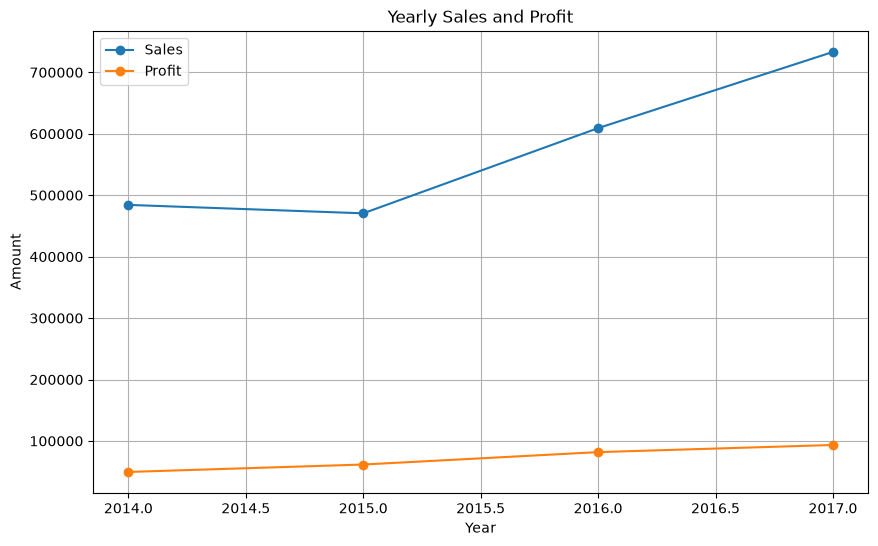

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(yearly_sales.index, yearly_sales.values, marker="o", label="Sales")
plt.plot(yearly_profit.index, yearly_profit.values, marker="o", label="Profit")

plt.title("Yearly Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Amount")

plt.legend()
plt.grid(True)

plt.savefig("screenshots/yearly_sales_profit.png", bbox_inches="tight")

plt.show()

### Observation

Sales increased from 484,247.50 in 2014 to 733,215.26 in 2017, while profit increased from 49,543.97 to 93,439.27. Although sales declined slightly in 2015, both sales and profit showed strong growth from 2015 onwards, with 2017 recording the highest sales and profit.

### Business Insight

The business shows a positive overall growth trend, with 2017 being the strongest year. The company should continue the strategies that supported the growth in sales and profit while monitoring pricing, discounts, and operating costs to maintain profitability.

In [39]:
sales_by_category = data.groupby("Category")["Sales"].sum()

print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


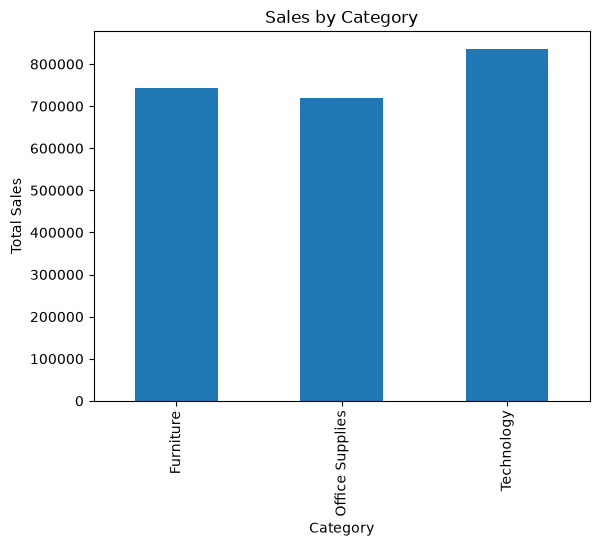

In [40]:
sales_by_category.plot(kind="bar", title="Sales by Category")

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Business Insight

Technology has the highest total sales among the three categories, followed by Furniture and Office Supplies. This indicates that Technology products contribute the most to the company's sales. The business should continue focusing on Technology products while also exploring ways to improve sales in Furniture and Office Supplies.

In [42]:
profit_by_category = data.groupby("Category")["Profit"].sum()

print(profit_by_category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


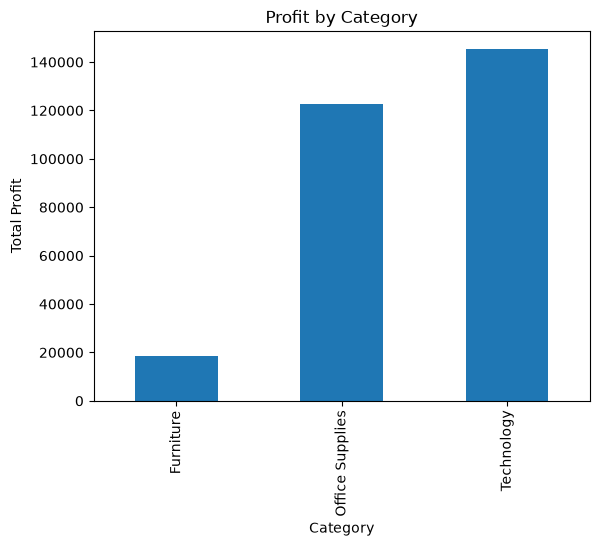

In [43]:
profit_by_category.plot(kind="bar", title="Profit by Category")

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

### Business Insight

Technology generates the highest profit, followed by Office Supplies. Furniture has the lowest profit despite having significant sales. This suggests that the business should review the pricing, discounts, and costs associated with Furniture products to improve their profitability.

In [45]:
sales_by_region = data.groupby("Region")["Sales"].sum()

print(sales_by_region)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


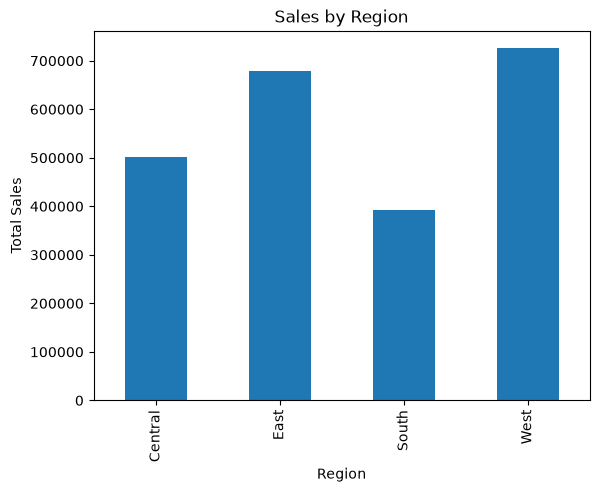

In [46]:
sales_by_region.plot(kind="bar", title="Sales by Region")

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

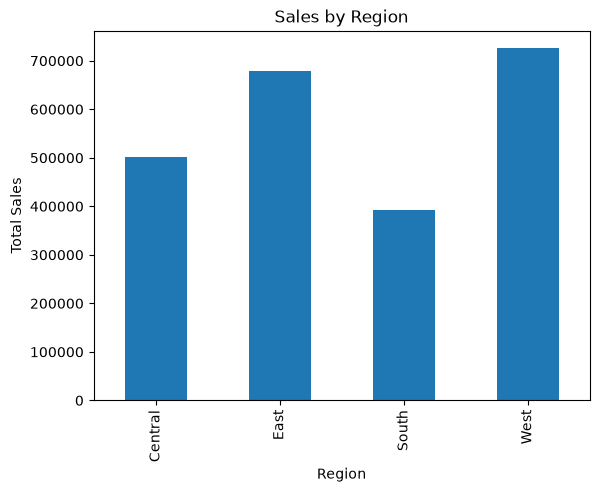

In [47]:
sales_by_region.plot(kind="bar", title="Sales by Region")

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

### Business Insight

The West region has the highest sales, followed by the East, Central, and South regions. The South region has the lowest sales, indicating an opportunity to improve sales performance through targeted marketing, promotions, and customer engagement strategies.

In [49]:
profit_by_region = data.groupby("Region")["Profit"].sum()

print(profit_by_region)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


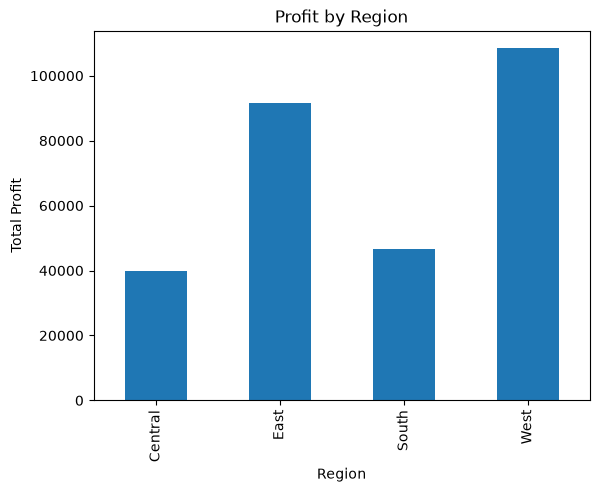

In [50]:
profit_by_region.plot(kind="bar", title="Profit by Region")

plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

### Business Insight

The West region generates the highest profit, followed by the East region. The Central region has the lowest profit. The business should maintain the successful strategies used in the West while identifying opportunities to improve profitability in the Central and South regions.

In [52]:
sales_by_segment = data.groupby("Segment")["Sales"].sum()

print(sales_by_segment)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


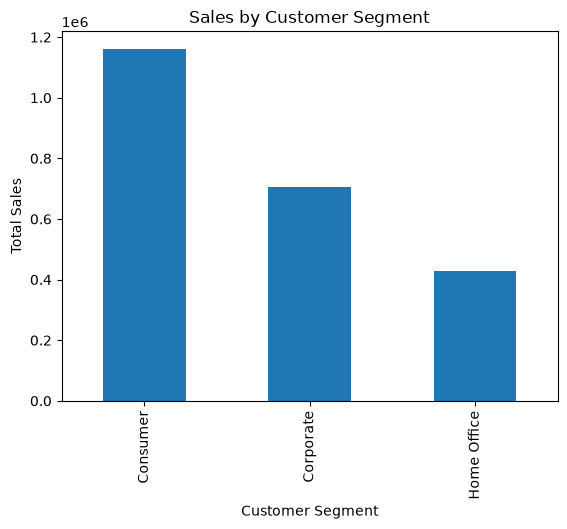

In [53]:
sales_by_segment.plot(kind="bar", title="Sales by Customer Segment")

plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

### Business Insight

The Consumer segment generates the highest sales, followed by the Corporate segment. The Home Office segment has the lowest sales. The business should continue focusing on Consumer customers while developing targeted marketing strategies to increase sales from Corporate and Home Office customers.

In [55]:
profit_by_segment = data.groupby("Segment")["Profit"].sum()

print(profit_by_segment)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


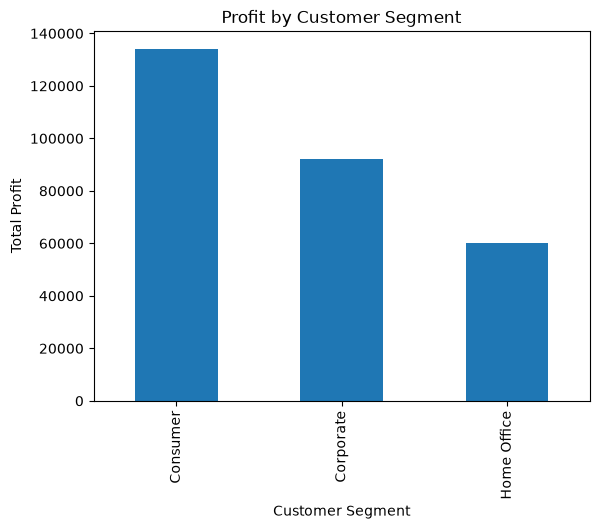

In [56]:
profit_by_segment.plot(kind="bar", title="Profit by Customer Segment")

plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.show()

### Business Insight
The Consumer segment generates the highest profit, followed by the Corporate segment. The Home Office segment generates the lowest profit. Since Consumer customers contribute the most to both sales and profit, the business should continue focusing on this segment while developing strategies to improve the performance of the Home Office segment.

In [57]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

monthly_sales = data.groupby(data["Order Date"].dt.month)["Sales"].sum()

print(monthly_sales)

Order Date
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


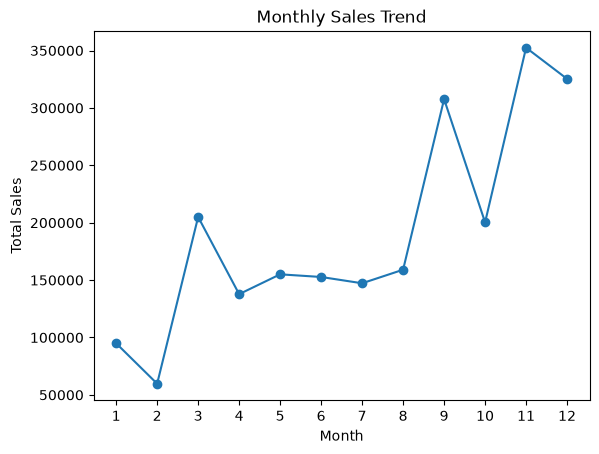

In [58]:
monthly_sales.plot(kind="line", marker="o", title="Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.show()

### Business Insight

Sales vary considerably across the months, with the highest sales recorded in November, followed by December and September. February has the lowest sales. The increase in sales toward the end of the year suggests a possible seasonal pattern, so the business should prepare sufficient inventory and marketing campaigns during high-demand periods.

In [59]:
monthly_profit = data.groupby(data["Order Date"].dt.month)["Profit"].sum()

print(monthly_profit)

Order Date
1      9134.4461
2     10294.6107
3     28594.6872
4     11587.4363
5     22411.3078
6     21285.7954
7     13832.6648
8     21776.9384
9     36857.4753
10    31784.0413
11    35468.4265
12    43369.1919
Name: Profit, dtype: float64


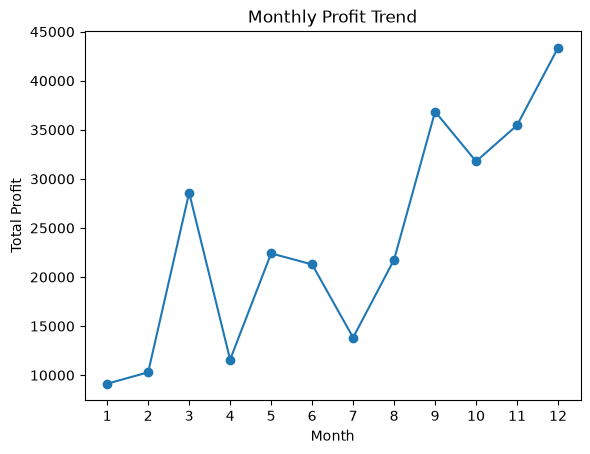

In [60]:
monthly_profit.plot(kind="line", marker="o", title="Monthly Profit Trend")

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(range(1, 13))
plt.show()

### Business Insight

Profit varies across the months, with the highest profit recorded in December, followed by September and November. February has the lowest profit. The stronger profitability toward the end of the year suggests a seasonal pattern, so the business should plan inventory, promotions, and resources carefully during high-demand periods.

In [61]:
discount_profit = data.groupby("Discount")["Profit"].mean()

print(discount_profit)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


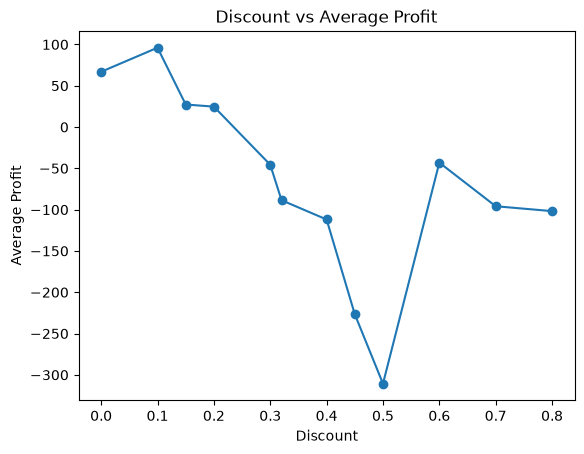

In [62]:
discount_profit.plot(kind="line", marker="o", title="Discount vs Average Profit")

plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

### Business Insight

The analysis shows that higher discount levels generally reduce average profit. Discounts of 30% and above result in negative average profit in this dataset, with the largest loss occurring at a 50% discount. The business should therefore use high discounts carefully and evaluate their impact on profitability before offering them.

In [63]:
top_products_sales = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products_sales)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


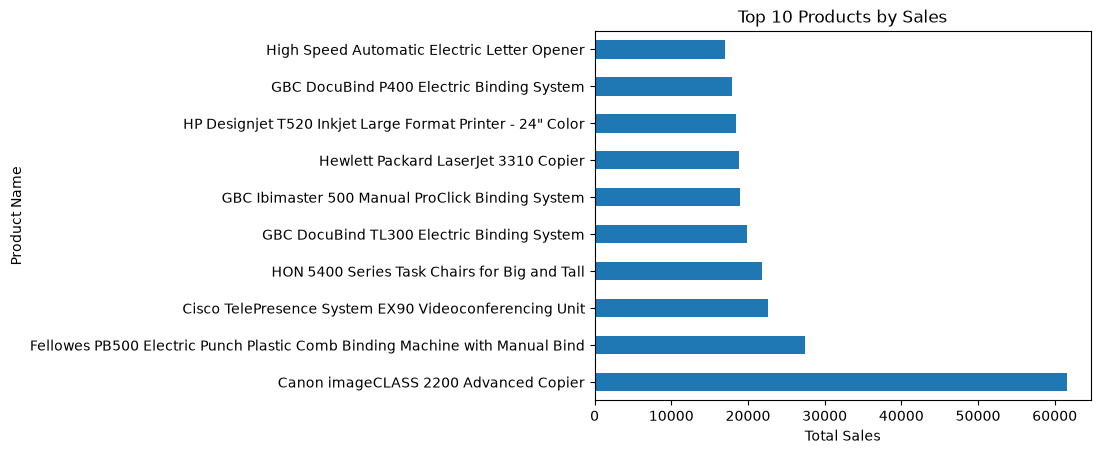

In [64]:
top_products_sales.plot(kind="barh", title="Top 10 Products by Sales")

plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

### Business Insight

The Canon imageCLASS 2200 Advanced Copier is the top-selling product, generating significantly higher sales than the other products in the top 10. The business should maintain sufficient stock of high-performing products and identify opportunities to promote other products with strong sales potential.

In [65]:
top_customers_sales = data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_customers_sales)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


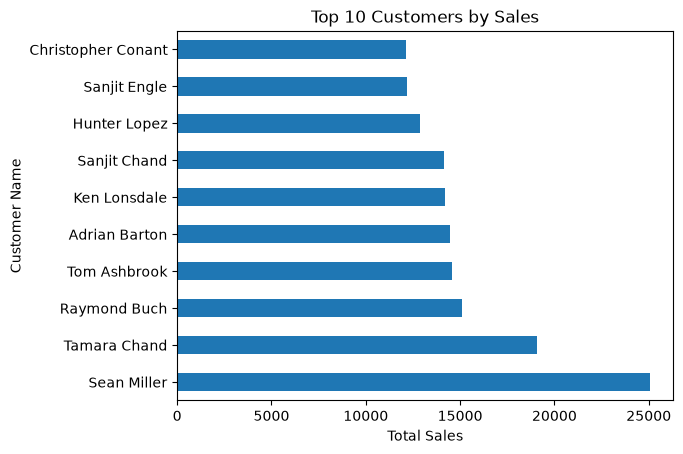

In [66]:
top_customers_sales.plot(kind="barh", title="Top 10 Customers by Sales")

plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.show()

### Business Insight

Sean Miller is the top customer by total sales, followed by Tamara Chand and Raymond Buch. These high-value customers contribute significantly to the company's revenue. The business should focus on retaining these customers through good service, personalized offers, and customer relationship strategies.

In [67]:
correlation = data[["Sales", "Profit", "Discount", "Quantity"]].corr()

print(correlation)

             Sales    Profit  Discount  Quantity
Sales     1.000000  0.479064 -0.028190  0.200795
Profit    0.479064  1.000000 -0.219487  0.066253
Discount -0.028190 -0.219487  1.000000  0.008623
Quantity  0.200795  0.066253  0.008623  1.000000


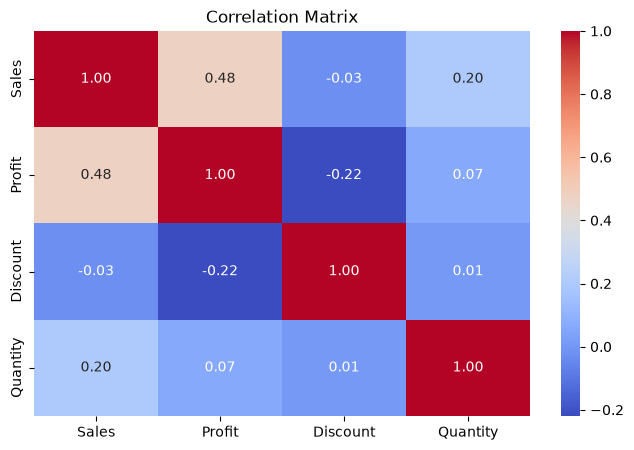

In [68]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

### Business Insight

Sales and Profit have a moderate positive relationship, indicating that higher sales are generally associated with higher profit. Discount and Profit have a negative relationship, suggesting that increasing discounts may reduce profitability. Sales and Quantity show a weak positive relationship, while the other relationships are very weak. The business should therefore focus on increasing sales while carefully managing discount levels.

In [69]:
print("Total Sales:", data["Sales"].sum())
print("Total Profit:", data["Profit"].sum())
print("Total Quantity Sold:", data["Quantity"].sum())
print("Average Discount:", data["Discount"].mean())
print("Average Profit:", data["Profit"].mean())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity Sold: 37873
Average Discount: 0.1562027216329798
Average Profit: 28.65689630778467


## Top 10 Products by Profit

In [70]:
top_products_profit = data.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

print(top_products_profit)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


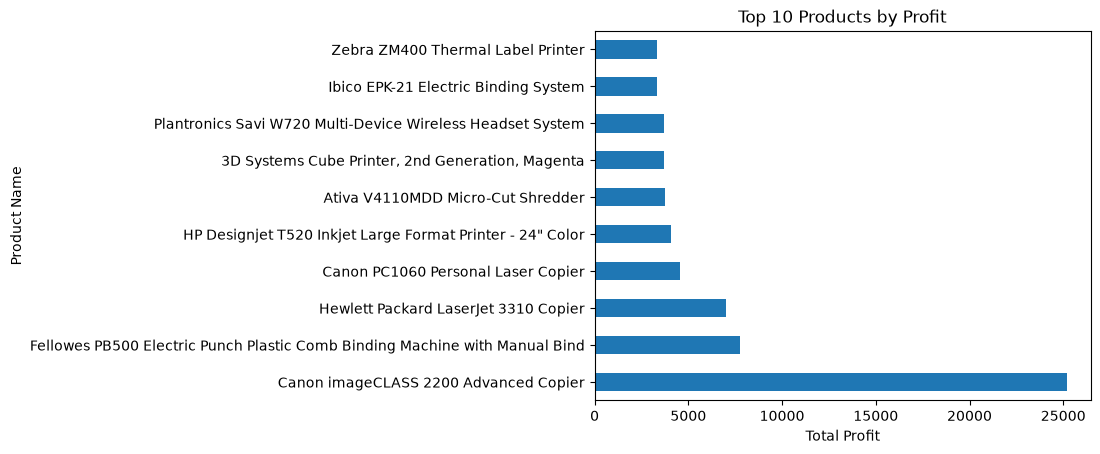

In [71]:
top_products_profit.plot(kind="barh", title="Top 10 Products by Profit")

plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.show()

### Business Insight

The top customers by profit make a significant contribution to the company's overall profitability. These high-value customers should be retained through good customer service, personalized offers, and strong customer relationship strategies. Focusing on profitable customers can help the business maintain sustainable growth.

## Final Business Insights and Conclusion

### Key Business Insights

- The company generated total sales of **$2.30 million** and total profit of **$286.40 thousand**.
- **Technology** is the strongest product category in both sales and profit.
- The **West region** has the highest sales and profit among all regions.
- The **Consumer segment** contributes the highest sales and profit.
- Sales and profit show stronger performance toward the **end of the year**, especially during September, November, and December.
- Higher discount levels generally reduce profitability, with discounts of **30% or more** resulting in negative average profit in this dataset.
- The **Canon imageCLASS 2200 Advanced Copier** is the top-selling product.
- **Sean Miller** is the top customer by total sales.
- Sales and Profit have a **moderate positive relationship**, while Discount and Profit have a negative relationship.

### Conclusion

The analysis shows that the business is performing positively overall, with strong contributions from Technology products, the West region, and Consumer customers. However, the negative relationship between discounts and profit indicates that excessive discounting can reduce profitability. The business should focus on high-performing products and customer segments, prepare for increased demand during high-sales months, and carefully manage discount strategies. These insights can help the business improve sales performance while maintaining sustainable profitability.